# Training convergence analysis (ensemble)

Reads per-seed training history written by `TrainingHistoryCallback`
(`plots/<prefix>_seed*/training.npz`) and produces the paper's convergence /
reproducibility figures by aggregating **across seeds**:

- **Fig 1 (main)** — multi-year-ENSO `mye_lift` learning curve: median + IQR band.
- **Fig 2 (main)** — per-seed final-lift distribution with a bootstrap 95% CI.
- **Fig 3 (main/supp)** — reward learning curve: median + IQR band.
- **Fig 4 (supplement)** — PPO optimization diagnostics (4-panel).
- **Convergence criterion** — quantitative plateau check on the median lift.

Following rliable / Empirical-Design-in-RL: report the median with a percentile
band (robust to non-normal cross-seed spread) and a bootstrap CI, not mean±std.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path('..').resolve()))
from utils.nb_helper import _load_npz, _median_iqr, _bootstrap_ci

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
BLUE, RED, GRAY = "#4878CF", "#D65F5F", "#999999"

# Which run family to aggregate. train_ensemble.py writes each seed's history to
# plots/<PREFIX>/train_seed<N>.npz (co-located with that prefix's inference.npz),
# so this globs the whole ensemble. Change PREFIX to point elsewhere.
PREFIX = "model10"
ROOT = Path('..') / 'plots'
OUTDIR = ROOT / 'train_analysis'
OUTDIR.mkdir(parents=True, exist_ok=True)

paths = sorted((ROOT / PREFIX).glob('train_seed*.npz'))
assert paths, f'no train_seed*.npz found under {ROOT / PREFIX}'
runs = [_load_npz(p) for p in paths]
seed_names = [p.stem for p in paths]
print(f'Loaded {len(runs)} seeds: {seed_names}')

Loaded 10 seeds: ['train_seed0', 'train_seed1', 'train_seed2', 'train_seed3', 'train_seed4', 'train_seed5', 'train_seed6', 'train_seed7', 'train_seed8', 'train_seed9']


In [2]:
def stack_metric(runs, t_key, v_key, n_grid=200):
    """Interpolate metric `v_key` (timed by `t_key`) onto a common grid across seeds.

    Returns (grid, mat) where mat is [n_seeds, n_grid]. The grid spans the overlap of
    all seeds (robust to a seed having an extra final point). NaNs are dropped before
    interpolation, so the first PPO update (empty logger) doesn't poison the curve.
    """
    def finite_t(r):
        t = np.asarray(r[t_key], float)
        return t[np.isfinite(t)]
    t_lo = max(finite_t(r).min() for r in runs)
    t_hi = min(finite_t(r).max() for r in runs)
    grid = np.linspace(t_lo, t_hi, n_grid)
    rows = []
    for r in runs:
        t = np.asarray(r[t_key], float)
        v = np.asarray(r[v_key], float)
        m = np.isfinite(t) & np.isfinite(v)
        rows.append(np.interp(grid, t[m], v[m]) if m.sum() >= 2
                    else np.full(n_grid, np.nan))
    return grid, np.vstack(rows)


def plot_band(ax, grid, mat, color, label=None, seed_lines=True):
    """Median line + shaded IQR (25-75%) band, with faint per-seed lines."""
    med, q25, q75 = _median_iqr(mat, axis=0)
    # if seed_lines:
    #     for row in mat:
    #         ax.plot(grid, row, color=color, lw=0.6, alpha=0.22)
    ax.fill_between(grid, q25, q75, color=color, alpha=0.20)
    ax.plot(grid, med, color=color, lw=2.2, label=label)
    return med


def final_values(runs, t_key, v_key):
    """Last finite value of `v_key` for each seed (the converged endpoint)."""
    out = []
    for r in runs:
        v = np.asarray(r[v_key], float)
        v = v[np.isfinite(v)]
        out.append(v[-1] if v.size else np.nan)
    return np.array(out)


TS_LABEL = 'training timesteps (months)'

## Fig 1 — `mye_lift` learning curve (main)
Median lift across seeds with a 25–75% IQR band. The flat dashed line is the
zero-action baseline (lift = 0). Convergence = the median plateaus; reproducibility
= the band is narrow.

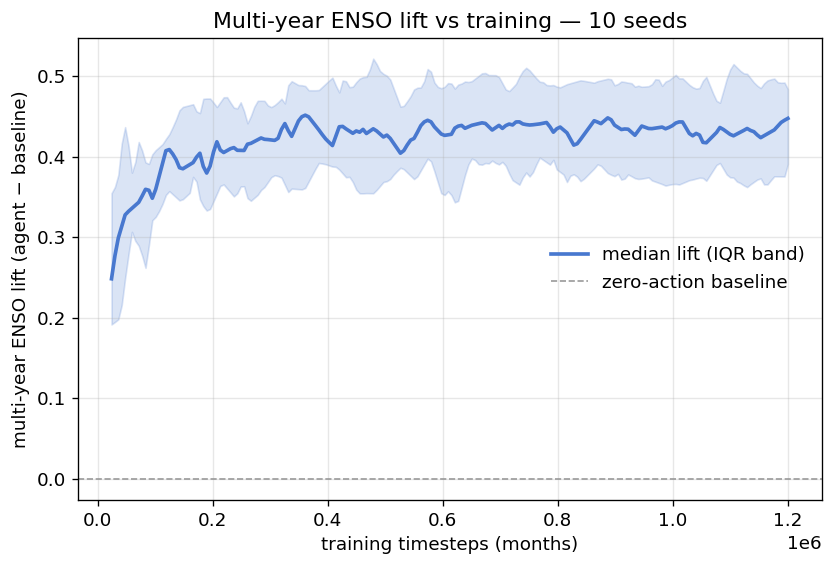

In [3]:
grid, mat = stack_metric(runs, 'eval_timesteps', 'eval_mye_lift')
fig, ax = plt.subplots(figsize=(8, 5))
plot_band(ax, grid, mat, BLUE, label='median lift (IQR band)')
ax.axhline(0, color=GRAY, ls='--', lw=1, label='zero-action baseline')
ax.set_xlabel(TS_LABEL)
ax.set_ylabel('multi-year ENSO lift (agent − baseline)')
ax.set_title(f'Multi-year ENSO lift vs training — {len(runs)} seeds')
ax.grid(True, alpha=0.3)
ax.legend(frameon=False)
fig.savefig(OUTDIR / 'fig1_mye_lift_curve.png', dpi=300, bbox_inches='tight')
plt.show()

## Fig 2 — final-performance distribution (main)
Each seed's converged lift, with a stratified-bootstrap 95% CI on the mean. This is
the reproducibility figure: it shows the result is not one lucky seed.

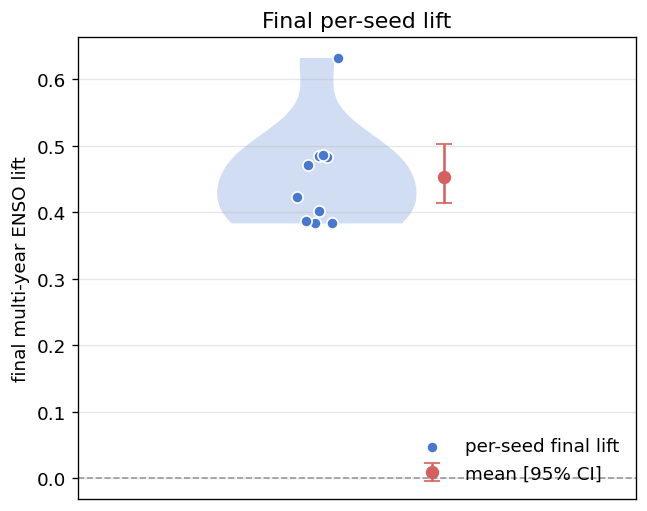

Headline: +45.3 pp lift [95% CI +41.3, +50.3] across 10 seeds


In [4]:
finals = final_values(runs, 'eval_timesteps', 'eval_mye_lift')
point, lo, hi = _bootstrap_ci(finals, np.mean)

fig, ax = plt.subplots(figsize=(6, 5))
if len(finals) > 1:
    vp = ax.violinplot(finals, positions=[0], showextrema=False)
    for b in vp['bodies']:
        b.set_facecolor(BLUE); b.set_alpha(0.25)
rng = np.random.default_rng(0)
ax.scatter(rng.normal(0, 0.04, len(finals)), finals, color=BLUE, s=45,
           edgecolor='w', zorder=3, label='per-seed final lift')
ax.errorbar(0.32, point, yerr=[[point - lo], [hi - point]], fmt='o', color=RED,
            capsize=5, ms=7, zorder=4, label='mean [95% CI]')
ax.axhline(0, color=GRAY, ls='--', lw=1)
ax.set_xticks([]); ax.set_xlim(-0.6, 0.8)
ax.set_ylabel('final multi-year ENSO lift')
ax.set_title('Final per-seed lift')
ax.grid(True, axis='y', alpha=0.3)
ax.legend(frameon=False, loc='lower right')
fig.savefig(OUTDIR / 'fig2_final_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Headline: {point*100:+.1f} pp lift '
      f'[95% CI {lo*100:+.1f}, {hi*100:+.1f}] across {len(finals)} seeds')

## Fig 3 — reward learning curve (main / supplement)
Mean step reward of each PPO rollout (the env trains continuously, so this is the
reward signal rather than episode return). Median + IQR across seeds.

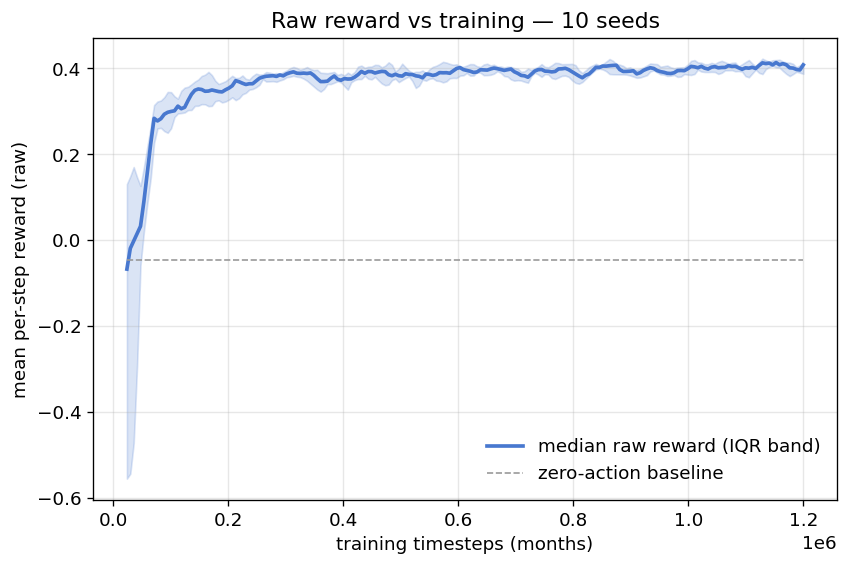

In [5]:
grid, mat = stack_metric(runs, 'eval_timesteps', 'eval_mean_reward')
fig, ax = plt.subplots(figsize=(8, 5))
plot_band(ax, grid, mat, BLUE, label='median raw reward (IQR band)')
# baseline reward is policy-independent → flat reference
bgrid, bmat = stack_metric(runs, 'eval_timesteps', 'eval_baseline_reward')
ax.plot(bgrid, np.nanmedian(bmat, axis=0), color=GRAY, ls='--', lw=1,
        label='zero-action baseline')
ax.set_xlabel(TS_LABEL)
ax.set_ylabel('mean per-step reward (raw)')
ax.set_title(f'Raw reward vs training — {len(runs)} seeds')
ax.grid(True, alpha=0.3); ax.legend(frameon=False)
fig.savefig(OUTDIR / 'fig3_reward_curve.png', dpi=300, bbox_inches='tight')
plt.show()


## Fig 4 — PPO optimization diagnostics (supplement)
A single "optimization was healthy and converged" panel. `explained_variance`
approaching/stabilizing high = the value function learned; small stable `approx_kl`
/ `clip_fraction` = no late policy lurching; `policy_std` settling = exploration
collapsing to exploitation.

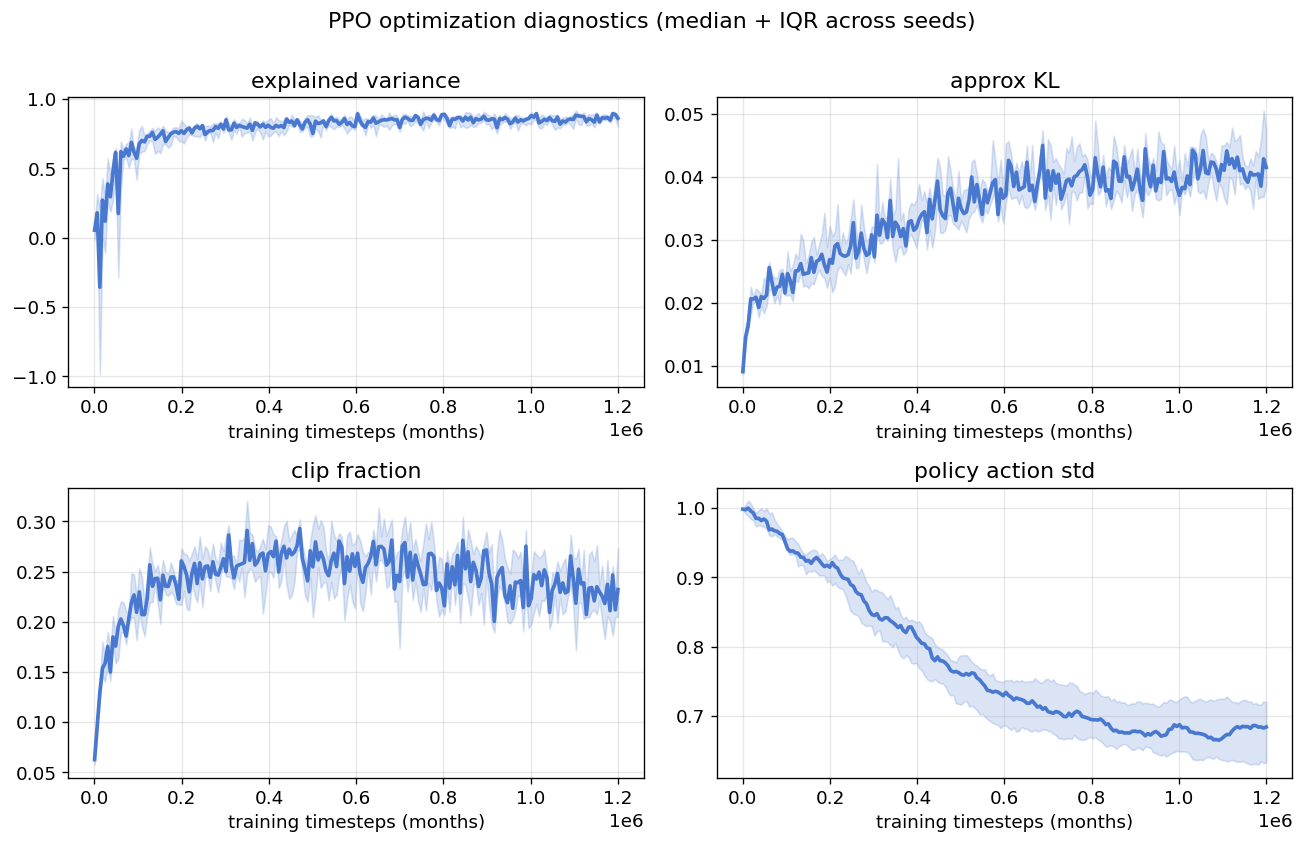

In [6]:
diag = [('explained_variance', 'explained variance'),
        ('approx_kl', 'approx KL'),
        ('clip_fraction', 'clip fraction'),
        ('policy_std', 'policy action std')]
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, (key, label) in zip(axes.ravel(), diag):
    grid, mat = stack_metric(runs, 'train_timesteps', key)
    plot_band(ax, grid, mat, BLUE)
    ax.set_title(label)
    ax.set_xlabel(TS_LABEL)
    ax.grid(True, alpha=0.3)
fig.suptitle('PPO optimization diagnostics (median + IQR across seeds)', y=1.0)
fig.tight_layout()
fig.savefig(OUTDIR / 'fig4_diagnostics.png', dpi=300, bbox_inches='tight')
plt.show()

## Convergence criterion
Quantitative plateau check on the median lift: the relative fluctuation
(range / |mean|) of the median curve over the final 20% of training. A small value
is the quotable convergence statement for the paper.

In [7]:
THRESH = 0.20  # relative fluctuation considered converged
grid, mat = stack_metric(runs, 'eval_timesteps', 'eval_mye_lift')
med, _, _ = _median_iqr(mat, axis=0)
win = grid >= grid.max() * 0.8
seg = med[win]
level = np.nanmean(seg)
rel = (np.nanmax(seg) - np.nanmin(seg)) / (abs(level) + 1e-9)
print(f'Final-20% window: {win.sum()} points, '
      f'[{grid[win][0]:.0f}, {grid[win][-1]:.0f}] timesteps')
print(f'Median lift level over final 20%: {level:+.3f} ({level*100:+.1f} pp)')
print(f'Relative fluctuation: {rel*100:.1f}%  (threshold {THRESH*100:.0f}%)')
print('=> CONVERGED' if rel < THRESH else '=> NOT yet plateaued')

Final-20% window: 41 points, [963618, 1200000] timesteps
Median lift level over final 20%: +0.432 (+43.2 pp)
Relative fluctuation: 7.0%  (threshold 20%)
=> CONVERGED
